# HW 1

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.preprocessing import MinMaxScaler

%matplotlib inline

# Загружаем выборку Diamonds

На данной выборке можно проверять работоспособность своего решения

1. PRICE: price in US dollars (326-18,823)
2. CARAT: weight of the diamond (0.2--5.01)
3. CUT: quality of the cut (Fair, Good, Very Good, Premium, Ideal)
4. COLOR: diamond colour, from J (worst) to D (best)
5. CLARITY: a measurement of how clear the diamond is (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
6. X: length in mm (0--10.74)
7. Y: width in mm (0--58.9)
8. Z: depth in mm (0--31.8)
9. DEPTH: total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)
10. TABLE: width of top of diamond relative to widest point (43--95)

In [15]:
diamonds_df = pd.read_csv('diamonds.csv')

In [16]:
diamonds_df.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


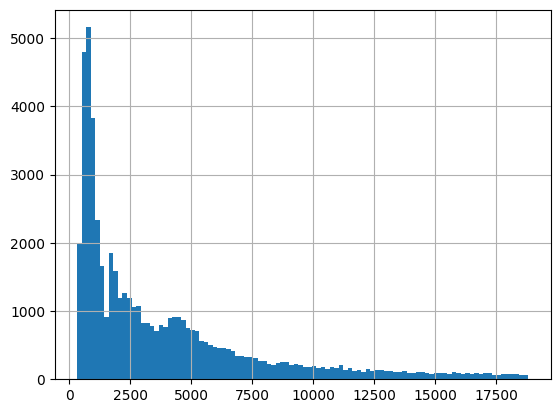

In [17]:
plt.hist(diamonds_df['price'], bins=100)
plt.grid();

# Подготовка данных

In [18]:
features = ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']
target = ['price']

In [19]:
cut_transform = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}
clarity_transform = {'I1': 0, 'SI2': 1, 'SI1': 2, 'VS2': 3, 'VS1': 4, 'VVS2': 5, 'VVS1': 6, 'IF': 7}
color_transorm = {'D': 0, 'E': 1, 'F': 2, 'G': 3, 'H': 4, 'I': 5, 'J': 6}

In [20]:
diamonds_df['cut'] = diamonds_df['cut'].apply(lambda x: cut_transform.get(x))
diamonds_df['color'] = diamonds_df['color'].apply(lambda x: color_transorm.get(x))
diamonds_df['clarity'] = diamonds_df['clarity'].apply(lambda x: clarity_transform.get(x))

In [47]:
X = diamonds_df[features].copy().values
y = diamonds_df[target].values

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=47, test_size=0.3)

In [49]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Обучаем модель линейной регрессии

In [24]:
reg = LinearRegression().fit(X_train, y_train)

In [25]:
y_pred = reg.predict(X_test)

In [26]:
score = r2_score(y_pred, y_test)

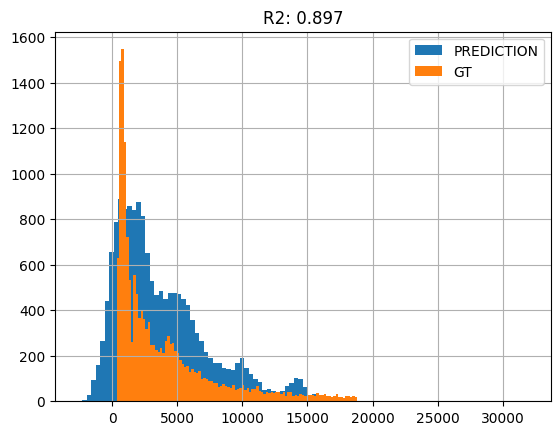

In [27]:
plt.title(f'R2: {str(score)[:5]}')
plt.hist(y_pred.reshape(1, -1)[0], bins=100, label='PREDICTION')
plt.hist(y_test.reshape(1, -1)[0], bins=100, label='GT')
plt.legend()
plt.grid();

# Задание 1: Реализация Gradient Descent для модели линейной регрессии

Ниже представлен шаблон кода, который необходимо дополнить, реализовав все указанные методы, и самостоятельно протестировать корректность решения. Можно (и даже нужно) добавлять свои методы для бОльшей читабельности кода

Достаточно будет, чтобы код работал для случая, когда X и y - np.ndarray

Внутри класса запрещается использовать сторонние библиотеки, кроме numpy

In [53]:
class LinearRegressorGD:

    def __init__(self, learning_rate=0.01, n_iter=1000):
        self.w = None
        self.b = None
        self.learning_rate = learning_rate
        self.n_iter = n_iter

    def fit(self, X, y):
        n = X.shape[0]
        self.w = np.zeros(X.shape[1])
        self.b = 0
        for i in range(self.n_iter): 
            y_pred = np.dot(X, self.w) + self.b
            err = y_pred - y.ravel()
            grad_w = (2 / n) * np.dot(X.T, err)
            grad_b = (2 / n) * np.sum(err)
            self.w -= self.learning_rate * grad_w
            self.b -= self.learning_rate * grad_b
        return self

    def predict(self, X):
        return np.dot(X, self.w) + self.b
        
    def get_params(self):
        return self.w, self.b


In [57]:
np.random.seed(42)
n_samples = 200
n_features = 3
X = np.random.rand(n_samples, n_features)
true_w = np.array([2.5, -1.7, 0.9])
true_b = 4.2
y = np.dot(X, true_w) + true_b + np.random.randn(n_samples) * 0.1
split = int(0.8 * n_samples)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

reg = LinearRegressorGD().fit(X_train, y_train)
y_pred = reg.predict(X_test)
score = r2_score(y_pred, y_test)
print(score)

0.865432303292102


# Задание 2: Реализация backpropagation для MLP

Ниже представлен шаблон кода, который необходимо дополнить, реализовав все указанные методы, и самостоятельно протестировать корректность решения. Можно (и даже нужно) добавлять свои методы для бОльшей читабельности кода

Достаточно будет, чтобы код работал для случая, когда X и y - np.ndarray

В качестве функции активации нужно использовать сигмоиду

Внутри класса запрещается использовать сторонние библиотеки, кроме numpy

In [3]:
class MLPRegressor:

    def __init__(self, input_size, output_size, hidden_layer_sizes=(100,), learning_rate=0.01, n_iter=100):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.learning_rate = learning_rate
        self.n = len(self.hidden_layer_sizes)
        self.n_iter = n_iter
        self.weights = []
        self.biases = []
        self.weights.append(np.random.randn(input_size, self.hidden_layer_sizes[0]) * 0.01)
        self.biases.append(np.zeros((1, self.hidden_layer_sizes[0])))
        for i in range(self.n - 1):
            self.weights.append(np.random.randn(self.hidden_layer_sizes[i], self.hidden_layer_sizes[i + 1]) * 0.01)
            self.biases.append(np.zeros((1, self.hidden_layer_sizes[i + 1])))
        self.weights.append(np.random.randn(self.hidden_layer_sizes[-1], output_size) * 0.01)
        self.biases.append(np.zeros((1, output_size)))

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def sigmoid_deriv(self, a):
        return a * (1 - a)
    
    def forward(self, X):
        self.activations = [X]
        self.z_ = []
        a = X
        for i in range(len(self.weights) - 1):
            z = np.dot(a, self.weights[i]) + self.biases[i]
            self.z_. append(z)
            a = self.sigmoid(z)
            self.activations.append(a)
        z = np.dot(a, self.weights[-1]) + self.biases[-1]
        self.z_.append(z)
        a = z
        self.activations.append(a)
        return a

    def backward(self, X, y):
        delta = self.activations[-1] - y
        m = X.shape[0]
        for i in range(len(self.weights) - 1, -1, -1):
            a = self.activations[i]
            grad_w = self.learning_rate * (np.dot(a.T, delta) / m)
            grad_b = self.learning_rate * (np.sum(delta, axis=0, keepdims=True) / m)
            self.weights[i] -= grad_w
            self.biases[i] -= grad_b
            if i > 0:
                delta = np.dot(delta, self.weights[i].T) * self.sigmoid_deriv(self.activations[i])

    def fit(self, X, y):
        for i in range(self.n_iter):
            self.forward(X)
            self.backward(X, y)

    def predict(self, X):
        return self.forward(X)


In [4]:

from sklearn.metrics import mean_squared_error


np.random.seed(42)
X = np.linspace(-1, 1, 500).reshape(-1, 1)
y = (X**3) + 0.1 * np.random.randn(*X.shape)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

model = MLPRegressor(input_size=1,
                     output_size=1,
                     hidden_layer_sizes=(50, 20),
                     learning_rate=0.05,
                     n_iter=1000)

model.fit(X_train, y_train)
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test  = mean_squared_error(y_test,  y_pred_test)
print(f"Train MSE: {mse_train:.5f}")
print(f"Test  MSE: {mse_test:.5f}")



Train MSE: 0.08764
Test  MSE: 0.51896
